## Построение графика мощности критерия

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

# Исходные данные
n1 = 139  # Размер выборки египетских черепов
n2 = 1000  # Размер выборки европейцев

# Стандартные отклонения для длины
s1_length = 5.722  # Египет
s2_length = 6.161  # Европейцы

# Стандартные отклонения для ширины
s1_width = 4.612   # Египет
s2_width = 5.055   # Европейцы

In [20]:
def calculate_power(n1, n2, s1, s2, alpha=0.05, n_points=100):
    df1 = n1 - 1
    df2 = n2 - 1
    
    F_crit_lower = f.ppf(alpha/2, df1, df2)
    F_crit_upper = f.ppf(1 - alpha/2, df1, df2)
    
    ratio_observed = (s2**2) / (s1**2)
    ratios = np.linspace(0.5, 2.0, n_points)
    
    power = []
    
    for ratio in ratios:
        p_lower = f.cdf(F_crit_lower / ratio, df1, df2)
        p_upper = 1 - f.cdf(F_crit_upper / ratio, df1, df2)
        
        power.append(p_lower + p_upper)
    
    return ratios, np.array(power), ratio_observed

ratios_length, power_length, ratio_obs_length = calculate_power(n1, n2, s1_length, s2_length)

ratios_width, power_width, ratio_obs_width = calculate_power(n1, n2, s1_width, s2_width)

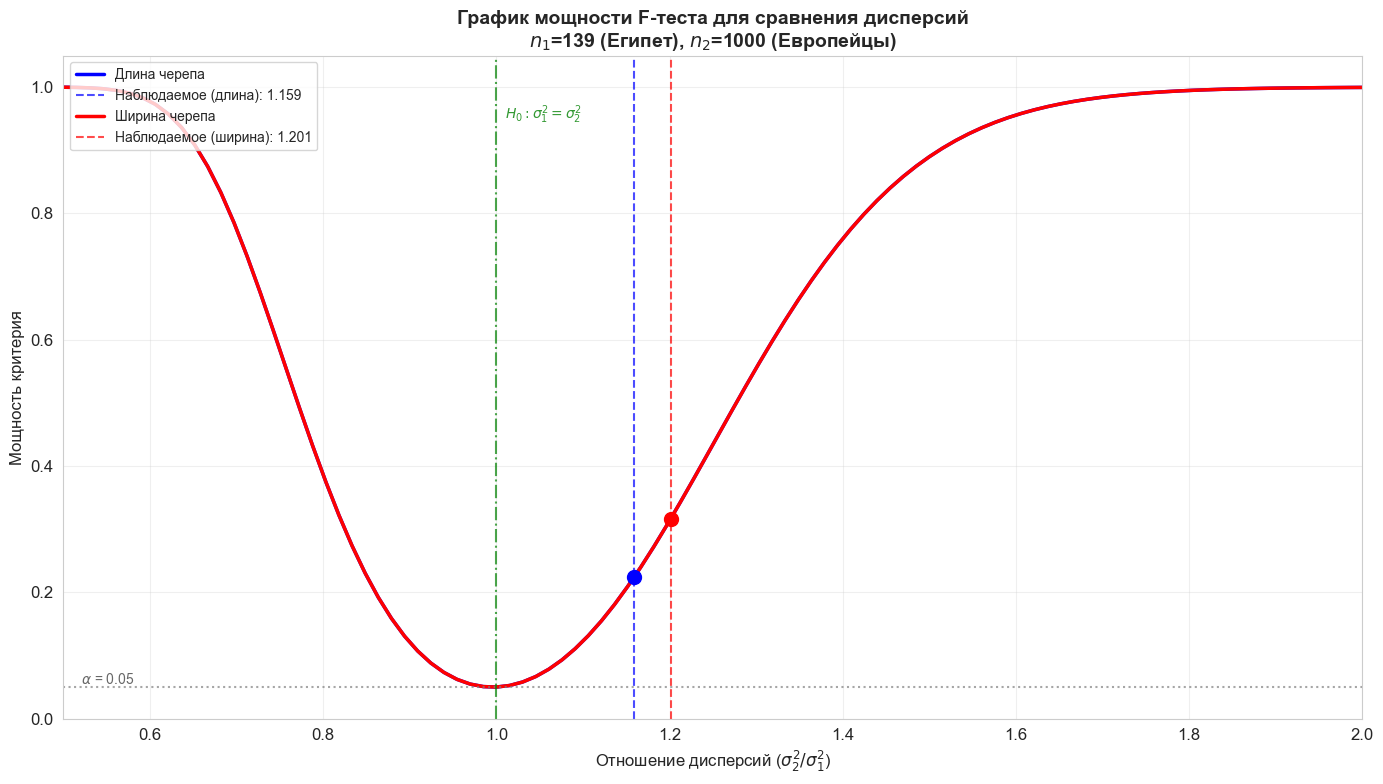

In [21]:
fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(ratios_length, power_length, 'b-', linewidth=2.5, label='Длина черепа')
ax.axvline(x=ratio_obs_length, color='blue', linestyle='--', 
           alpha=0.7, label=f'Наблюдаемое (длина): {ratio_obs_length:.3f}')
ax.scatter([ratio_obs_length], 
           [np.interp(ratio_obs_length, ratios_length, power_length)], 
           color='blue', s=100, zorder=5)

ax.plot(ratios_width, power_width, 'r-', linewidth=2.5, label='Ширина черепа')
ax.axvline(x=ratio_obs_width, color='red', linestyle='--', 
           alpha=0.7, label=f'Наблюдаемое (ширина): {ratio_obs_width:.3f}')
ax.scatter([ratio_obs_width], 
           [np.interp(ratio_obs_width, ratios_width, power_width)], 
           color='red', s=100, zorder=5)

ax.axhline(y=0.05, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(0.52, 0.055, r'$\alpha$ = 0.05', fontsize=10, alpha=0.7)

ax.set_xlabel(r'Отношение дисперсий ($\sigma_2^2 / \sigma_1^2$)', fontsize=12)
ax.set_ylabel('Мощность критерия', fontsize=12)

ax.set_title('График мощности F-теста для сравнения дисперсий\n'
             f'$n_1$={n1} (Египет), $n_2$={n2} (Европейцы)', fontsize=14, fontweight='bold')
             
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.5, 2.0)
ax.set_ylim(0, 1.05)

ax.axvline(x=1.0, color='green', linestyle='-.', linewidth=1.5, alpha=0.7)
ax.text(1.01, 0.95, r'$H_0: \sigma_1^2 = \sigma_2^2$', fontsize=10, color='green', alpha=0.8)

plt.tight_layout()
plt.show()